In [1]:
import numpy as np
import pandas as pd 
import re
from tqdm import tqdm
from glob import glob
import seaborn as sns
import gzip 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
from glob import glob
from tqdm import tqdm
from pybedtools import BedTool
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
from datasketch import MinHash
import edlib
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu, wilcoxon
import gzip 
import re
# plt.style.use("/Users/danilodubocanin/work/publication.mplstyle")
import warnings
warnings.filterwarnings("ignore")
from matplotlib.patches import Rectangle
import edlib
from matplotlib.collections import BrokenBarHCollection
import os 
import scipy.stats as ss

In [3]:


tar1_df = pd.read_csv("data_for_submission/all_tar1.clean.bed", 
                      sep="\t", 
                      header=None, 
                      usecols=[0,1,2,3],
                      names=['contig','start','stop','sat_name'])

telo_df = pd.read_csv("data_for_submission/all_telos.bed.gz", 
                      sep="\t", 
                      header=None, 
                      usecols=[0,1,2,3],
                      names=['contig','start','stop','direction'])

# compute telomere end coordinate
telo_df["tel_end"] = telo_df.apply(
    lambda r: r.stop if r.direction == "-" else r.start,
    axis=1
)

# merge telomere info into satellite intervals
m = tar1_df.merge(telo_df[["contig", "tel_end"]], on="contig")

# keep only intervals that fall within 10kb of tel_end
res = m[
    (m["start"] <= m["tel_end"] + 10_000) &
    (m["stop"]  >= m["tel_end"] - 10_000)
]



def normalize_chrom_assignment(df: pd.DataFrame,
                               chrom_assignment_col: str = "chrom_assignment",
                               pos_col: str = "centering_position") -> pd.DataFrame:
    """
    Cleans chrom_assignment by:
      1. Removing underscores and everything after them.
      2. Keeping canonical chr1–22, X, Y, M (including double digits).
      3. Assigning p/q arm based on suffix or centering_position.
    """

    def clean_and_assign(s, pos):
        if not isinstance(s, str):
            return None

        # Strip everything after underscore (e.g., _alt, _random)
        base = re.sub(r'_.*', '', s)

        # Match canonical chromosomes up to chr22
        m = re.match(r'^(chr(?:1[0-9]|2[0-2]|[1-9]|X|Y|M))', base)
        if not m:
            return None
        chrom_base = m.group(1)

        # Determine arm
        if base.endswith("p") or base.endswith("q"):
            arm = base[-1]
        else:
            try:
                arm = "q" if float(pos) > 100_000 else "p"
            except (TypeError, ValueError):
                arm = None

        return f"{chrom_base}{arm}" if arm else chrom_base

    df[chrom_assignment_col] = [
        clean_and_assign(s, p) for s, p in zip(df[chrom_assignment_col], df[pos_col])
    ]
    return df



import zlib
from matplotlib import cm, colors

DNA_COMP = str.maketrans("ACGTacgtnN", "TGCAtgcaNn")
def rc(s): 
    return s.translate(DNA_COMP)[::-1]

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    base = cm.get_cmap(cmap) if isinstance(cmap, str) else cmap
    return colors.ListedColormap(base(np.linspace(minval, maxval, n)))

class HashKmerColorManager:
    def __init__(self, k=6, canonical="CCCTAA",
                 cmap="cubehelix_r", cmap_min=0.15, cmap_max=0.95,
                 tie_rc=False, pin_canonical=True):
        self.k = k
        self.canonical = canonical.upper()
        self.cmap = truncate_colormap(cmap, cmap_min, cmap_max)
        self.tie_rc = tie_rc
        self.pin_canonical = pin_canonical
        self.cache_hex = {}
        self.cache_rgba = {}
        self.gray_hex = "#bfbfbf"
        self.gray_rgba = (0.75, 0.75, 0.75, 1.0)

    def _key(self, kmer: str) -> str:
        kmer = kmer.upper()
        if self.tie_rc:
            rcmer = rc(kmer)
            return kmer if kmer <= rcmer else rcmer
        return kmer

    def _scalar(self, key: str) -> float:
        """CRC32 hash -> [0,1) scalar."""
        h = zlib.crc32(key.encode("utf-8")) & 0xffffffff
        return (h / 0xffffffff)  # normalized float 0–1

    def _is_canonical_fragment(self, kmer: str) -> bool:
        return len(kmer) > 0 and kmer.upper() == self.canonical[:len(kmer)]

    def color_hex(self, kmer: str) -> str:
        key = self._key(kmer)
        if key in self.cache_hex:
            return self.cache_hex[key]

        if self.pin_canonical and self._is_canonical_fragment(key):
            self.cache_hex[key] = self.gray_hex
            return self.gray_hex

        s = self._scalar(key)
        rgba = self.cmap(s)
        rgb = tuple(int(255 * c) for c in rgba[:3])
        hexcol = f"#{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}"
        self.cache_hex[key] = hexcol
        return hexcol

    def color_rgba(self, kmer: str):
        key = self._key(kmer)
        if key in self.cache_rgba:
            return self.cache_rgba[key]

        if self.pin_canonical and self._is_canonical_fragment(key):
            self.cache_rgba[key] = self.gray_rgba
            return self.gray_rgba

        s = self._scalar(key)
        rgba = self.cmap(s)
        self.cache_rgba[key] = rgba
        return rgba

k=6
cmgr = HashKmerColorManager(
    k=k,
    canonical="TTAGGG",
    cmap="turbo",   
    cmap_min=0.05,     # skip pale start
    cmap_max=0.95,    # skip darkest end
    tie_rc=True,
    pin_canonical=False
)



def get_label_from_series(series: pd.Series) -> str:
    """
    Split first non-null value in series by '#' and combine
    first two parts with '_', e.g. 'HG01346#2#JBHDSS...' → 'HG01346_2'.
    """
    if series.empty or series.isna().all():
        return "unknown"
    first_val = series.dropna().iloc[0]
    parts = str(first_val).split("#")
    if len(parts) >= 2:
        return f"{parts[0]}_{parts[1]}"
    return parts[0]
        
    
    
chrom_alias = pd.read_csv('data_for_submission/all_diploid_alias.txt',
                          sep="\t",
                          header=None,
                          names=['id','chrom','contig']
                         )

# build id -> chrom mapping from chrom_alias
id_to_chr = dict(zip(chrom_alias['id'], chrom_alias['chrom']))

def read_in_tsv(file,id_to_chr):
    
    col_names = ['chrom',
         'centering_position',
         'strand',
         'subset_sequence',
         'reference_start',
         'reference_end',
         'query_name',
         'RG',
         'HP',
         'centered_query_start',
         'centered_query_end',
         'query_length',
         '5mC_pos',
         '5mC_score',
         'query_sequence']
    
    
    
    sample_id = file.split('.')[0].split('/')[-1]
    sample_tsv = pd.read_csv(file,sep="\t",index_col=False,header=None,
                        usecols = [0,1,2,3,4,5,6,7,8,9,10,11,14,15,21],names=col_names,skiprows=1)
    
    sample_id = file.split('.')[0]

       # map sample contig IDs to base chromosome names (e.g., "chr1")
    sample_tsv['chr_base'] = sample_tsv['chrom'].map(id_to_chr)

    # if centering_position > 100kb → 'q', else 'p'
    threshold = 100_000
    sample_tsv['chrom_assignment'] = (
        sample_tsv['chr_base'] + np.where(sample_tsv['centering_position'].astype(int) > threshold, 'q', 'p')
    )

    # optional: drop helper column
    sample_tsv.drop(columns=['chr_base'], inplace=True)

    return sample_tsv

def rotations(s: str):
    return [s[i:] + s[:i] for i in range(len(s))]

def ID_TVR_PHASE_DISRUPTION_SIMPLIFIED(s):
    # 1) Determine strand via cyclic 6-mer matches (Kept for robust strand detection)
    plus6  = rotations("CCCTAA")   # cyclic perms (plus)
    minus6 = rotations("TTAGGG")   # cyclic perms (minus)

    pat_plus6  = re.compile(r"(?=(?:%s))" % "|".join(plus6),  re.I)
    pat_minus6 = re.compile(r"(?=(?:%s))" % "|".join(minus6), re.I)

    plus_idx  = np.fromiter((m.start() for m in pat_plus6.finditer(s)),  dtype=int)
    minus_idx = np.fromiter((m.start() for m in pat_minus6.finditer(s)), dtype=int)

    is_plus  = (plus_idx.size >= minus_idx.size)
    true_idx = plus_idx if is_plus else minus_idx
    
    # If there are no telomeric patterns at all, there are no phase disruptions to map
    if true_idx.size == 0:
        return np.empty((0, 2), dtype=int)

    L = len(s)

    # 2) Find canonical 6-mer on chosen strand and build a boolean mask
    canon = "CCCTAA" if is_plus else "TTAGGG"
    pat_canon = re.compile(rf"(?={canon})", re.I)
    canon_idx = np.fromiter((m.start() for m in pat_canon.finditer(s)), dtype=int)

    # Use the fast difference array to mark all bases covered by the canonical motif
    diff = np.zeros(L + 1, dtype=np.int16)
    if canon_idx.size > 0:
        np.add.at(diff, canon_idx, 1)
        np.add.at(diff, canon_idx + 6, -1)
        
    canon_mask = np.cumsum(diff)[:L] > 0

    # 3) Return all continuous spans where the sequence is NOT canonical
    low = ~canon_mask  # Invert the mask: True where it is a variant/disruption
    d = np.diff(np.pad(low.astype(np.int8), (1, 1)))
    starts = np.where(d == 1)[0]
    ends   = np.where(d == -1)[0]
    
    # Return as [start, length] pairs
    spans  = np.column_stack([starts, ends - starts]).astype(int)
    
    return spans
    


def assignTVRAndAddTelomereSequenceColumn(tsv, 
              minimum_cutoff_for_read_length = 100, 
              maximum_cutoff_for_tvr_length = 300):
    
    teloseqs, tvrs = [], []
    
    for qn, grp in tsv.groupby("query_name", sort=False):
        seq = grp["query_sequence"].iloc[0]
        qe  = int(grp["centered_query_end"].iloc[0])

        if not isinstance(seq, str) or qe < minimum_cutoff_for_read_length:
            teloseq = ""
            tvr = np.empty((0,2), int)
        else:
            qe = min(qe, len(seq))
            teloseq = seq[-qe:]
            tvr = ID_TVR_PHASE_DISRUPTION_SIMPLIFIED(teloseq)
            # optionally filter overly long ones
            tvr = tvr[tvr[:,1] <= maximum_cutoff_for_tvr_length] if tvr.size else tvr

        # assign the same teloseq/tvr to all rows in this group
        teloseqs.extend([teloseq] * len(grp))
        tvrs.extend([tvr] * len(grp))

    # assign new columns back to tsv
    tsv = tsv.assign(teloseq=teloseqs, tvr=tvrs)
    
    return tsv
    


def assignTVRAndAddTelomereSequenceColumn(tsv, 
              minimum_cutoff_for_read_length = 100, 
             # maximum_cutoff_for_tvr_length = 300) # standard:
                                          maximum_cutoff_for_tvr_length = 300):
    
    teloseqs, tvrs = [], []
    
    for qn, grp in tsv.groupby("query_name", sort=False):
        seq = grp["query_sequence"].iloc[0]
        qe  = int(grp["centered_query_end"].iloc[0])

        if not isinstance(seq, str) or qe < minimum_cutoff_for_read_length:
            teloseq = ""
            tvr = np.empty((0,2), int)
        else:
            qe = min(qe, len(seq))
            teloseq = seq[-qe:]
            tvr = ID_TVR_PHASE_DISRUPTION_SIMPLIFIED(teloseq)
            # optionally filter overly long ones
            tvr = tvr[tvr[:,1] <= maximum_cutoff_for_tvr_length] if tvr.size else tvr

        # assign the same teloseq/tvr to all rows in this group
        teloseqs.extend([teloseq] * len(grp))
        tvrs.extend([tvr] * len(grp))

    # assign new columns back to tsv
    tsv = tsv.assign(teloseq=teloseqs, tvr=tvrs)
    
    return tsv


def sort_by_max_TVR_start(all_tsvs, chrom, dist_bp=300):
    
    ## need to max mean TVR start less than
    
    all_max_tvr_starts = []
    
    for tsv in all_tsvs:
        # 1. Restrict to the desired chromosome
        tmp = tsv[tsv.chrom_assignment == chrom]

        # 2. Extract valid TVRs (stored as arrays in the 'tvr' column)
        tvr_starts = []
        for arr in tmp.get("tvr", []):
            if isinstance(arr, np.ndarray) and arr.size:
                # filter by: start > 6 and size < dist_bp
                valid = arr[(arr[:, 0] < dist_bp) & (arr[:, 1] >= 30)]
                if valid.size:
                    tvr_starts.append(valid[:, 0].max())

        # 3. Take maximum valid TVR start or NaN if none
        max_start = np.nanmedian(tvr_starts) if tvr_starts else np.nan
        all_max_tvr_starts.append(max_start)

    # 4. Sort by that metric
    sort_order = np.argsort(np.nan_to_num(all_max_tvr_starts, nan=np.inf))
    return sort_order

In [5]:
chrom_alias = pd.read_csv('data_for_submission/all_diploid_alias.txt',
                          sep="\t",
                          header=None,
                          names=['id','chrom','contig']
                         )

id_to_chr = dict(zip(chrom_alias['id'], chrom_alias['chrom']))

col_names = ['chrom',
         'centering_position',
         'strand',
         'subset_sequence',
         'reference_start',
         'reference_end',
         'query_name',
         'RG',
         'HP',
         'centered_query_start',
         'centered_query_end',
         'query_length',
         '5mC_pos',
         '5mC_score',
         'query_sequence']


all_hprc_tsvs = []
all_hprc_labels = []
all_hprc_molecule_counts = [] 

for file in tqdm(glob("data_for_submission/centered_reads_fiberseq/*.v2.tsv.gz")):
        
        sample_tsv = pd.read_csv(file,
                          sep="\t",
                          index_col=False)
        sample_tsv['chr_base'] = sample_tsv['chrom'].map(id_to_chr)

        threshold = 100_000
        sample_tsv['chrom_assignment'] = (
            sample_tsv['chr_base'] + np.where(sample_tsv['centering_position'].astype(int) > threshold, 'q', 'p')
        )

        n_before = len(sample_tsv)

        req = np.ceil(0.001 * (sample_tsv["centered_query_end"] - sample_tsv["centered_query_start"]).astype(float)).astype(int)
        req = req.clip(lower=1)  # optional: require at least 1

        obs = sample_tsv["m6a_qual"].fillna("").str.strip(",").str.count(",") + 1
        sample_tsv = sample_tsv[obs >= req]

        print(f"Dropped {n_before - len(sample_tsv):,} rows (adaptive cutoff)")
        
        sample_tsv.drop(columns=['chr_base'], inplace=True)
        sample_tsv = normalize_chrom_assignment(sample_tsv)
        sample_tsv = sample_tsv[sample_tsv["chrom_assignment"].notna()]
        sample_tsv = assignTVRAndAddTelomereSequenceColumn(sample_tsv)
        all_hprc_tsvs.append(sample_tsv)
        all_hprc_labels.append(file.split("/")[-1].split('.')[0])


  0%|                                                                                                                                                        | 0/22 [00:00<?, ?it/s]

Dropped 150 rows (adaptive cutoff)


  5%|██████▌                                                                                                                                         | 1/22 [00:03<01:18,  3.73s/it]

Dropped 314 rows (adaptive cutoff)


  9%|█████████████                                                                                                                                   | 2/22 [00:07<01:11,  3.57s/it]

...

 91%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████             | 20/22 [01:24<00:07,  3.98s/it]

Dropped 547 rows (adaptive cutoff)


 95%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌      | 21/22 [01:28<00:03,  3.83s/it]

Dropped 383 rows (adaptive cutoff)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [01:32<00:00,  4.22s/it]


In [6]:

tvr_rates_by_sample = []      
non_rates_by_sample = []     

for tsv in tqdm(all_hprc_tsvs):
    tvr_rates = []
    non_rates = []
    
    for _, row in tsv.iterrows():
        size = len(row.teloseq)
        if size < 1000:
            continue

        m6a_bool = np.zeros(size, dtype=bool)
        tvr_bool = np.zeros(size, dtype=bool)

        m6a_arr = np.array(row.centered_m6a_positions.split(','))[1:-1].astype(int)
        
        if row.strand == "-": 
            m6a_arr = m6a_arr - 1
        
        m6a_arr = m6a_arr[(m6a_arr > 0) & (m6a_arr < size)]
        if m6a_arr.size == 0:
            continue
        m6a_bool[m6a_arr] = True

        seq = np.frombuffer(row.teloseq.encode("ascii"), dtype="S1")
        
        m6a_bases = seq[m6a_bool]
        target_base = m6a_bases[0]

        for sub_tvr_start, sub_tvr_size in row.tvr[1:-1]:
            start = max(0, sub_tvr_start)
            end   = min(size, sub_tvr_start + sub_tvr_size)
            if end > start:
                if target_base in seq[start:end]:
                    tvr_bool[start:end] = True

        non_bool = ~tvr_bool

        tvr_seq = seq[tvr_bool]
        denom_tvr = np.sum(tvr_seq == target_base) 

        non_seq = seq[non_bool]
        denom_non = np.sum(non_seq == target_base)

        tvr_m6a = np.sum(m6a_bool & tvr_bool)
        non_m6a = np.sum(m6a_bool & non_bool)

        if denom_tvr != 0:
            tvr_rate = tvr_m6a / denom_tvr
            tvr_rates.append(tvr_rate)
        if denom_non != 0:
            non_rate = non_m6a / denom_non
            non_rates.append(non_rate)

    tvr_rates_by_sample.append(np.asarray(tvr_rates, dtype=float))
    non_rates_by_sample.append(np.asarray(non_rates, dtype=float))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:09<00:00,  2.23it/s]


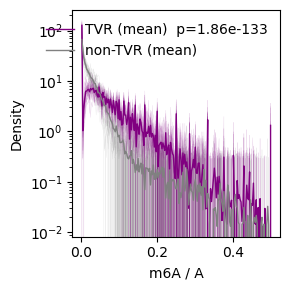

<Figure size 640x480 with 0 Axes>

In [8]:
bins = np.linspace(0, 0.5, 200)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

tvr_hists = []
non_hists = []

tvr_all = np.concatenate([np.asarray(x, float) for x in tvr_rates_by_sample if len(x) > 0])
non_all = np.concatenate([np.asarray(x, float) for x in non_rates_by_sample if len(x) > 0])

tvr_all = tvr_all[np.isfinite(tvr_all)]
non_all = non_all[np.isfinite(non_all)]

res = mannwhitneyu(tvr_all, non_all, alternative="two-sided")
p = res.pvalue

plt.figure(figsize=(3, 3))

for tvr_rate, non_tvr_rate in zip(tvr_rates_by_sample, non_rates_by_sample):
    if len(tvr_rate) == 0 or len(non_tvr_rate) == 0:
        continue

    h_tvr, _ = np.histogram(tvr_rate, bins=bins, density=True)
    h_non, _ = np.histogram(non_tvr_rate, bins=bins, density=True)

    tvr_hists.append(h_tvr)
    non_hists.append(h_non)

    plt.plot(bin_centers, h_tvr, color='purple', alpha=0.15, lw=0.3)
    plt.plot(bin_centers, h_non, color='gray',   alpha=0.15, lw=0.3)

tvr_hists = np.vstack(tvr_hists)
non_hists = np.vstack(non_hists)

tvr_mean = tvr_hists.mean(axis=0)
non_mean = non_hists.mean(axis=0)

plt.plot(bin_centers, tvr_mean, color='purple', lw=1, label=f'TVR (mean)  p={p:.2e}')
plt.plot(bin_centers, non_mean, color='gray',   lw=1, label='non-TVR (mean)')

plt.yscale('log')
plt.xlabel('m6A / A')
plt.ylabel('Density')
plt.legend(frameon=False)
plt.tight_layout()


plt.show()
plt.clf()



100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:26<00:00,  1.21s/it]


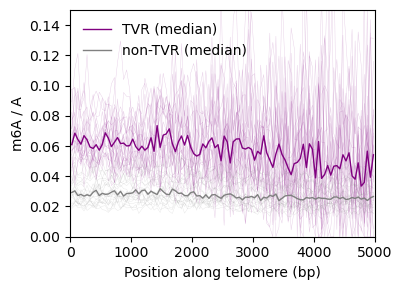

<Figure size 640x480 with 0 Axes>

In [9]:
from collections import defaultdict

BIN = 50
MAX_LEN = 5_000   
bins = np.arange(0, MAX_LEN + BIN, BIN)
bin_centers = bins[:-1] + BIN / 2

tvr_bin_values_by_sample = []  
non_bin_values_by_sample = []

for tsv in tqdm(all_hprc_tsvs):
    
    tvr_bins = defaultdict(list)
    non_bins = defaultdict(list)
    
    for _, row in tsv.iterrows():
        size = len(row.teloseq)
        if size < 1000:
            continue

        m6a_bool = np.zeros(size, dtype=bool)
        tvr_bool = np.zeros(size, dtype=bool)

        m6a_arr = np.array(row.centered_m6a_positions.split(','))[1:-1].astype(int)
        
        if row.strand == "-":
            m6a_arr = m6a_arr - 1
        
        m6a_arr = m6a_arr[(m6a_arr > 0) & (m6a_arr < size)]
        if m6a_arr.size == 0:
            continue
        m6a_bool[m6a_arr] = True

        seq = np.frombuffer(row.teloseq.encode("ascii"), dtype="S1")
        
        m6a_bases = seq[m6a_bool]
        target_base = m6a_bases[0]

        for sub_tvr_start, sub_tvr_size in row.tvr[1:-1]:
            start = max(0, sub_tvr_start)
            end   = min(size, sub_tvr_start + sub_tvr_size)
            if end > start:
                if target_base in seq[start:end]:
                    tvr_bool[start:end] = True

        for i, (b0, b1) in enumerate(zip(bins[:-1], bins[1:])):
            if b0 >= size:
                break
            b1 = min(b1, size)
            sl = slice(b0, b1)
            
            mask = tvr_bool[sl]
            if mask.any():
                denom_tvr = np.sum(seq[sl][mask] == target_base)
                if denom_tvr != 0:
                    rate = np.sum(m6a_bool[sl][mask]) / denom_tvr
                    tvr_bins[i].append(rate)

            mask = ~tvr_bool[sl]
            if mask.any():
                denom_non = np.sum(seq[sl][mask] == target_base)
                if denom_non != 0:
                    rate = np.sum(m6a_bool[sl][mask]) / denom_non
                    non_bins[i].append(rate)

    tvr_bin_values_by_sample.append(tvr_bins)
    non_bin_values_by_sample.append(non_bins)


tvr_curves = []    
non_curves = []

n_bins = len(bins) - 1

for tb, nb in zip(tvr_bin_values_by_sample, non_bin_values_by_sample):

    tvr_mean = np.full(n_bins, np.nan)
    non_mean = np.full(n_bins, np.nan)

    for i in range(n_bins):
        if i in tb and len(tb[i]) > 0:
            tvr_mean[i] = np.nanmean(tb[i])
        if i in nb and len(nb[i]) > 0:
            non_mean[i] = np.nanmean(nb[i])

    tvr_curves.append(tvr_mean)
    non_curves.append(non_mean)

tvr_curves = np.vstack(tvr_curves)
non_curves = np.vstack(non_curves)


plt.figure(figsize=(4, 3))

# ---- per-sample faint lines ----
for y in tvr_curves:
    plt.plot(bin_centers, y, color="purple", alpha=0.2, lw=0.3)

for y in non_curves:
    plt.plot(bin_centers, y, color="gray", alpha=0.2, lw=0.3)

# ---- bold median across samples ----
plt.plot(
    bin_centers,
    np.nanmedian(tvr_curves, axis=0),
    color="purple",
    lw=1,
    label="TVR (median)"
)

plt.plot(
    bin_centers,
    np.nanmedian(non_curves, axis=0),
    color="gray",
    lw=1,
    label="non-TVR (median)"
)

plt.xlabel("Position along telomere (bp)")
plt.ylabel("m6A / A")
plt.legend(frameon=False)
plt.tight_layout()
plt.ylim(0,0.15)
plt.xlim(0,5_000)
plt.show()
plt.clf()

In [10]:
def mean_autocorrelation_with_tvr_load(m6a_arrays, max_lag=2000,subtelo=False):
    """
    Compute mean normalized autocorrelation across molecules.
    m6a_arrays: list of 1D numpy arrays (0/1)
    max_lag: maximum lag in bp to compute ACF for
    """
    acfs = []
    for arr in tqdm(m6a_arrays):
        arr = np.asarray(arr, dtype=float)
        if len(arr) < max_lag:
            continue
        if len(arr) > 10_000:
            if subtelo:
                arr = arr[-10_000:]
        if arr.sum() == 0:
            continue
            
            
        arr = arr[:5000]
        arr -= arr.mean()                     # remove DC offset
        corr = np.correlate(arr, arr, mode="full")
        mid = len(corr) // 2
        corr = corr[mid - max_lag: mid + max_lag + 1]
        corr /= corr[max_lag]                 # normalize by lag-0 value
        acfs.append(corr)
    if not acfs:
        return None
    return np.nanmean(acfs, axis=0)

def get_m6a_binaries_with_tvr_load(
    tsv: pd.DataFrame,
    min_telo_len: int = 1_500,
    max_telo_len: int = 20_000,
):
    for chrom, df_c in tsv.groupby('chrom'):
        for centering_position, df_telo in df_c.groupby('centering_position'):
            for ns_str, ne_str, m6a_str, query_size, telo_len,tvr_arr in zip(
                df_telo.centered_nuc_starts,
                df_telo.centered_nuc_ends,
                df_telo.centered_m6a_positions,
                df_telo.query_length,
                df_telo.centered_query_end,df_telo.tvr):
                if not (isinstance(ns_str, str) and isinstance(ne_str, str)):
                    continue
                if int(query_size) < 15_000:
                    continue

                ns = np.fromstring(ns_str, sep=',', dtype=int)
                ne = np.fromstring(ne_str, sep=',', dtype=int)
                ds = ne - ns
                m6a = np.fromstring(m6a_str, sep=',', dtype=int)

                if len(m6a) < 100:
                    continue
                if len(m6a) / query_size < 0.005:
                    continue
                if len(ns) < 10:
                    continue
                if telo_len < min_telo_len or telo_len > max_telo_len:
                    continue

                L = int(telo_len)
                m6a_bin = np.zeros(L, dtype=np.uint8)
                tmp_m6a = m6a[(m6a >= 0) & (m6a < L)]
                m6a_bin[tmp_m6a] = 1
                m6a_bin_telo = m6a_bin 
                
                L = int(query_size) - int(telo_len)
                m6a_bin = np.zeros(L, dtype=np.uint8)
                tmp_m6a = m6a[(m6a < 0)] + L
                m6a_bin[tmp_m6a] = 1
                m6a_bin_subtelo = m6a_bin 
                tvr_load = sum(tvr_arr[:,1])
                yield m6a_bin_telo, m6a_bin_subtelo, chrom, centering_position,tvr_load

                
all_m6a_bin_telo = []
all_m6a_bin_subtelo = []
all_tvr_load = []
for tsv, label in tqdm(zip(all_hprc_tsvs, all_hprc_labels)):
    
    for telo_binary, subtelo_binary, chrom,centering_position,tvr_load in get_m6a_binaries_with_tvr_load(tsv):
        
        
        all_tvr_load.append(tvr_load)
        all_m6a_bin_telo.append(telo_binary)
        all_m6a_bin_subtelo.append(subtelo_binary)
        

22it [00:01, 19.08it/s]


deciles: 86.0 884.0


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1577/1577 [00:15<00:00, 98.60it/s]

troughs and peaks: (array([102, 260, 415, 575, 733]), array([179, 341, 497, 653, 820]))
troughs and peaks: (array([102, 264, 426, 589, 753]), array([179, 341, 502, 664, 833]))
bottom 10%, peaks and troughs


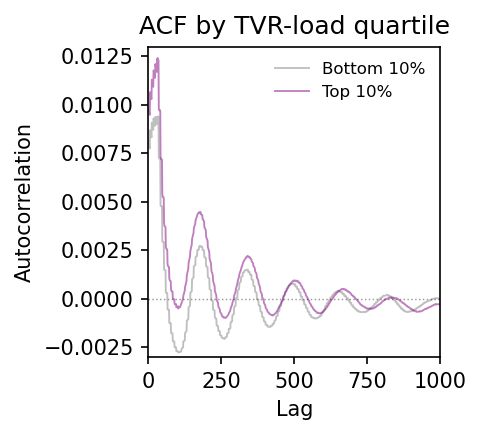

troughs and peaks: (array([102, 260, 415, 575]), array([341, 497, 653, 820]))
bottom 10%, deltas of peak-to-trough: [0.00426031 0.00356222 0.00224316 0.00143083]
top 10%, peaks and troughs
troughs and peaks: (array([102, 264, 426, 589]), array([341, 502, 664, 833]))
top 10%, deltas of peak-to-trough: [0.00270647 0.00319086 0.00181218 0.00127103]
high tvr / low tvr, deltas of peak-to-trough change percentage: 11.168123037127273


<Figure size 640x480 with 0 Axes>

In [14]:
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d
def smooth_boxcar(y, w):
    w = int(w)
    if w <= 1:
        return np.asarray(y, dtype=float)
    k = np.ones(w, dtype=float) / w
    return np.convolve(np.asarray(y, dtype=float), k, mode="same")

def first_n_trough_peak_deltas(
    acf,
    smooth_w=60,
    pos_prominence=0.0001,
    min_dist=80,
    n=10
):
    N=2000
    acf = np.asarray(acf, float)
    acf = acf[:N][::-1]
    y = uniform_filter1d(acf, size=smooth_w)

    # find peaks and troughs
    beginning_spacer = 50
    peaks, _ = find_peaks(y[beginning_spacer:], prominence=pos_prominence, distance=min_dist)
    troughs, _ = find_peaks(-y[beginning_spacer:], prominence=pos_prominence/2, distance=min_dist)
        
    peaks = peaks + beginning_spacer
    troughs = troughs + beginning_spacer
    
    print(f'troughs and peaks: {troughs[:n],peaks[:n]}')
    deltas = []

    for t in troughs:
        p_after = peaks[peaks > t]
        if len(p_after) == 0:
            continue
        p = p_after[0]
        deltas.append(y[p] - y[t])
        if len(deltas) == n:
            break

    return np.array(deltas)


def plot_quartile_acfs(quartile_acf, x=None, alpha=0.7, lw=1.0, figsize=(3.2, 3.0), 
                       title="ACF by TVR-load quartile",w=60):

    plt.figure(figsize=figsize, dpi=150)
    
    order = ["Bottom 10%",  "Top 10%"]
    
    for name in order:
        acf = quartile_acf.get(name, None)
        if acf is None:
            continue
        acf = np.asarray(acf).astype(float)
        N = 2000
        x = np.arange(N)

        telo_y = np.asarray(acf[:N][::-1], dtype=float)

        telo_y = np.asarray(acf[:N][::-1], dtype=float)
        if name == "Bottom 10%":
            
            plt.plot(x, smooth_boxcar(telo_y,w), alpha=alpha, lw=lw, label=name,c='gray')
        elif name == "Top 10%":
            
            plt.plot(x, smooth_boxcar(telo_y,w), alpha=alpha, lw=lw, label=name,c='purple')
        else:
            plt.plot(x, smooth_boxcar(telo_y,w), alpha=alpha, lw=lw, label=name)

    plt.axhline(0, lw=0.7, alpha=0.4,ls='dotted',c='black')
    plt.xlabel("Lag")
    plt.ylabel("Autocorrelation")
    plt.title(title)
    plt.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.xlim(0,1000)
    plt.ylim(-.003,.013)
    plt.show()
    plt.clf()


tvr_load_arr = np.asarray(all_tvr_load)
rng = np.random.default_rng(0)

# decile cutoffs
p10, p90 = np.percentile(tvr_load_arr, [10, 90])
print("deciles:", p10, p90)

decile_bounds = [
    ("Bottom 10%", -np.inf, p10),
    ("Top 10%",    p90,      np.inf),
]


decile_acf = {}

for name, lo, hi in decile_bounds:
    idx = np.where((tvr_load_arr >= lo) & (tvr_load_arr <= hi))[0]

    decile_acf[name] = mean_autocorrelation_with_tvr_load(
        [all_m6a_bin_telo[i] for i in idx]
    )
    
    
delta_by_dist = {}

for label, acf in decile_acf.items():
    if acf is None:
        delta_by_dist[label] = np.full(4, np.nan)
        continue
    delta_by_dist[label] = first_n_trough_peak_deltas(acf, n=5)

np.divide(delta_by_dist['Top 10%'],delta_by_dist['Bottom 10%'])

print('bottom 10%, peaks and troughs')
plot_quartile_acfs(decile_acf, alpha=0.5, lw=0.9,w=60)
low_deltas = first_n_trough_peak_deltas( # bottom
    decile_acf["Bottom 10%"],
    smooth_w=60,
    pos_prominence=.0001,
    min_dist=150,
    n=4
)

print(f'bottom 10%, deltas of peak-to-trough: {low_deltas}')
print('top 10%, peaks and troughs')

high_deltas = first_n_trough_peak_deltas( # top 
    decile_acf["Top 10%"],
    smooth_w=60,
    pos_prominence=.0001,
    min_dist=150,
    n=4
)
print(f'top 10%, deltas of peak-to-trough: {high_deltas}')

print(f'high tvr / low tvr, deltas of peak-to-trough change percentage: {100 - (high_deltas[-1] / low_deltas[-1]) * 100 }')


  0%|                                                                                                                                                        | 0/22 [00:00<?, ?it/s]

HG01928#1


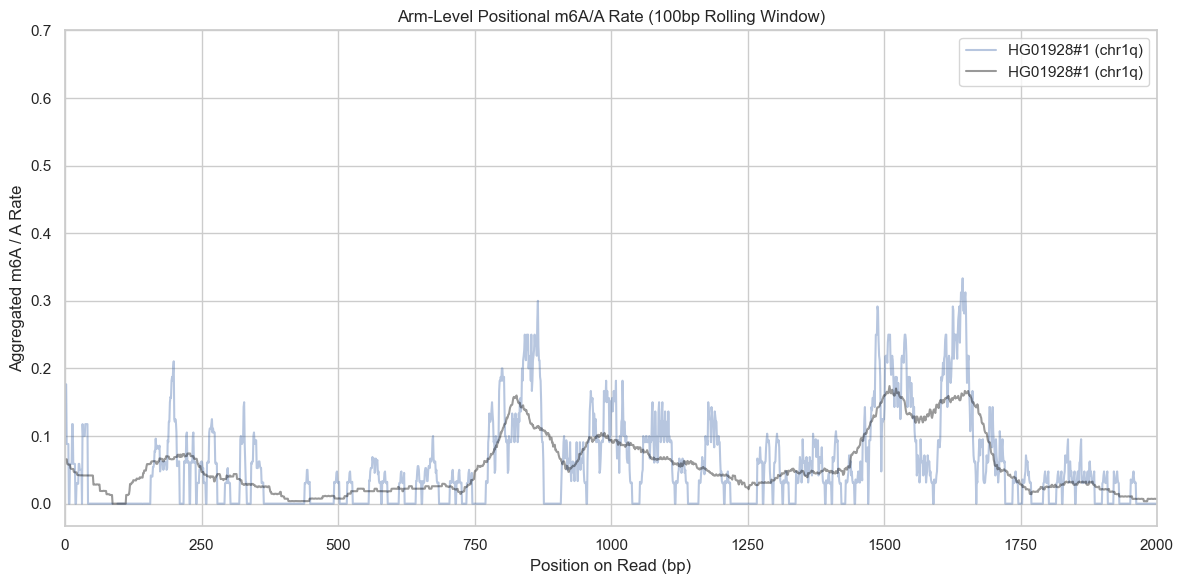

  9%|█████████████                                                                                                                                   | 2/22 [00:00<00:01, 10.61it/s]

HG01978#2


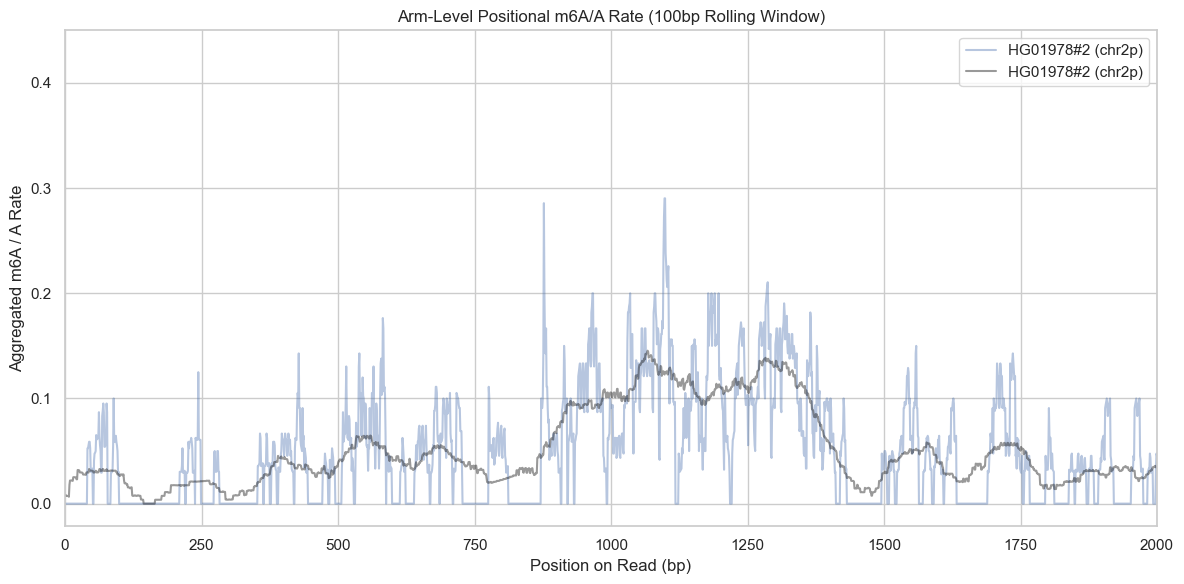

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 59.74it/s]


In [33]:
def _parse_m6a_positions(x):

    if x is None:
        return np.array([], dtype=int)

    try:
        if isinstance(x, float) and np.isnan(x):
            return np.array([], dtype=int)
    except Exception:
        pass

    if isinstance(x, (list, tuple, np.ndarray)):
        arr = np.asarray(x)
        if arr.size == 0:
            return np.array([], dtype=int)
        return arr.astype(int, copy=False)

    if isinstance(x, str):
        s = x.strip()
        if not s or s.lower() in {"nan", "none"}:
            return np.array([], dtype=int)

        if s[0] == "[" and s[-1] == "]":
            s = s[1:-1].strip()


        arr = np.fromstring(s, sep=",", dtype=int)
        if arr.size == 0:
            arr = np.fromstring(s, sep=" ", dtype=int)
        return arr.astype(int, copy=False) if arr.size else np.array([], dtype=int)

    return np.array([], dtype=int)

def plotTVRs(
    all_tsvs, chrom_end,
    dist_bp=2_000,
    figsize=(5,9),
    only_labels=None,
    spacing_between_mols=2,
    spacing_between_individuals=5,
    cmgr=cmgr,                       
    min_reads_per_group=5,
    min_tvr_size=1,
    max_tvr_size=1_000,
    population_df=None,              
    out_name=None,flip=False
):
  
    fig, ax = plt.subplots(figsize=figsize)
    canonical_gray = "whitesmoke"
    y_offset = 0
    y_labels, y_positions = [], []
    side_spans = []  

    contigs_present = []
    for tsv in all_tsvs:
        tmp = tsv[tsv.chrom_assignment == chrom_end]
        if "chrom" in tmp.columns and len(tmp):
            contigs_present.extend(tmp["chrom"].astype(str).unique().tolist())
    contigs_present = list(dict.fromkeys(contigs_present))

    for contig in contigs_present:
        row_start = y_offset
        any_plotted = False
        first_label_for_contig = None

        min_y_for_bars = None
        max_y_for_bars = None

        for tsv in all_tsvs:
            tmp = tsv[(tsv.chrom_assignment == chrom_end) & (tsv.chrom == contig)]
            if tmp.empty:
                continue

            grouped = (
                tmp.assign(span=tmp["centered_query_end"].astype(int))
                   .sort_values("span", ascending=True)
                   .groupby(["chrom", "centering_position"])
            )

            for (chrom_, center_pos), group in grouped:
                if len(group) < min_reads_per_group:
                    continue

                label = get_label_from_series(group["chrom"])
                if (only_labels is not None) and (label not in only_labels):
                    continue

                for row in group.itertuples():
                    seq = getattr(row, "query_sequence")
                    qe  = int(getattr(row, "centered_query_end"))
                    if not isinstance(seq, str) or qe < 1_000:
                        continue

                    teloseq = getattr(row, "teloseq")
                    L = min(qe, dist_bp)
                    tvr = getattr(row, "tvr")

                    segments_by_color = {}
                    for start, length in zip(list(tvr[:, 0]), (tvr[:, 1])):
                        if length < min_tvr_size or length > max_tvr_size:
                            continue
                        if start >= dist_bp:
                            break

                        pos = int(start)
                        end = start + length
                        while pos < end:
                            frag_len = min(k, end - pos)    # uses your global k
                            frag_end = pos + frag_len
                            frag = teloseq[pos:frag_end]
                            if not frag:
                                break
                            color = cmgr.color_rgba(frag)
                            run_end = frag_end
                            stride = frag_len
                            while run_end + stride <= end and teloseq[run_end:run_end + stride] == frag:
                                run_end += stride
                            segments_by_color.setdefault(color, []).append((pos, run_end - pos))
                            pos = run_end

                    if len(segments_by_color) < 1:
                        continue

                    ax.add_patch(Rectangle(
                        (0, y_offset - 0.4), L, 0.8,
                        color=canonical_gray, lw=0, antialiased=False, alpha=1
                    ))
                    for color, spans in segments_by_color.items():
                        coll = BrokenBarHCollection(
                            xranges=spans,
                            yrange=(y_offset - 0.4, 0.8),
                            facecolors=[color],
                            edgecolors=[color],
                            linewidths=0.1,
                            antialiased=False,
                        )
                        ax.add_collection(coll)
                                        # --- m6A overlay (centered_m6a_positions > 0) ---
                    m6a = _parse_m6a_positions(getattr(row, "centered_m6a_positions", None))
                    if m6a.size:
                        m6a = m6a[(m6a > 0) & (m6a < dist_bp)]  # only positive + within plotted window
                        if m6a.size:
                            ax.vlines(
                                m6a,
                                y_offset - 1, y_offset + 1,
                                lw=0.5,
                                color="purple",
                                alpha=1,
                                zorder=10,
                            )

                    y0 = y_offset - 0.4
                    y1 = y0 + 0.8
                    min_y_for_bars = y0 if min_y_for_bars is None else min(min_y_for_bars, y0)
                    max_y_for_bars = y1 if max_y_for_bars is None else max(max_y_for_bars, y1)

                    y_offset += spacing_between_mols
                    any_plotted = True
                    if first_label_for_contig is None:
                        first_label_for_contig = label

                if any_plotted:
                    y_offset += spacing_between_individuals

        if any_plotted:
            if (min_y_for_bars is not None) and (max_y_for_bars is not None):
                y_positions.append((min_y_for_bars + max_y_for_bars) / 2.0)
                row_label = first_label_for_contig if first_label_for_contig is not None else contig
                y_labels.append(row_label)
                side_spans.append((min_y_for_bars, max_y_for_bars, row_label))

            y_offset += spacing_between_individuals

    ax.set_xlim(0, dist_bp)
    ax.set_ylim(-2, y_offset + 25)
    ax.set_xlabel("Distance from subtelomere boundary (bp)")
    ax.set_ylabel("Molecule index (across all individuals)")
    ax.set_title(f"{chrom_end}")

    if len(y_positions) != len(y_labels):
        m = min(len(y_positions), len(y_labels))
        y_positions = y_positions[:m]
        y_labels    = y_labels[:m]

    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=2.5)
    ax.tick_params(axis='both', which='both', bottom=True, left=True, labelbottom=True, labelleft=True)
    ax.tick_params(axis='y', which='minor', left=False)
    ax.set_rasterization_zorder(1)



    plt.tight_layout()
    if out_name:
        plt.savefig(out_name, dpi=350)
        plt.show()
        plt.clf()
    else:
        plt.show()
        


sample_to_arm = {'HG01978#2': 'chr2p', 'HG01928#1': 'chr1q'}

tvr_rates_by_sample = []      
non_rates_by_sample = []      


for tsv in tqdm(all_hprc_tsvs):

    row_samples = tsv.chrom.str.split('#').str[:2].str.join('#')
    
    unique_samples = row_samples.unique()
    
    for sample in ['HG01978#2', 'HG01928#1']:
        
        if sample not in unique_samples:
            continue
        print(sample)
        arm = sample_to_arm[sample]
        
        tmp_tsv = tsv[(row_samples == sample) & (tsv.chrom_assignment == arm)]
        
        if tmp_tsv.empty:
            continue

        max_len = tmp_tsv.teloseq.str.len().max()
        
        total_m6a_counts = np.zeros(max_len)
        total_target_bases = np.zeros(max_len)
        fig, ax = plt.subplots(figsize=(12, 6))

        for _, row in tmp_tsv.iterrows():
            size = len(row.teloseq)

            m6a_bool = np.zeros(size, dtype=bool)
            tvr_bool = np.zeros(size, dtype=bool)

            m6a_arr = np.array(row.centered_m6a_positions.split(','))[2:-2].astype(int)

            if row.strand == "-":
                m6a_arr = m6a_arr - 1

            m6a_arr = m6a_arr[(m6a_arr >= 0) & (m6a_arr < size)]
            if m6a_arr.size > 0:
                m6a_bool[m6a_arr] = True
            else:
                continue

            seq = np.frombuffer(row.teloseq.encode("ascii"), dtype="S1")

            m6a_bases = seq[m6a_bool]
            target_base = m6a_bases[0]
            is_target_base = (seq == target_base)

            total_m6a_counts[:size] += (is_target_base & m6a_bool).astype(int)
            total_target_bases[:size] += is_target_base.astype(int)


        s_m6a = pd.Series(total_m6a_counts)
        s_targets = pd.Series(total_target_bases)


        rolling_m6a = s_m6a.rolling(window=10, center=True, min_periods=1).sum()
        rolling_targets = s_targets.rolling(window=10, center=True, min_periods=1).sum()


        aggregated_rate = rolling_m6a / rolling_targets

        ax.plot(aggregated_rate.index, aggregated_rate.values, label=f'{sample} ({arm})', linewidth=1.5,alpha=0.4)

        rolling_m6a = s_m6a.rolling(window=100, center=True, min_periods=1).sum()
        rolling_targets = s_targets.rolling(window=100, center=True, min_periods=1).sum()


        aggregated_rate = rolling_m6a / rolling_targets

        ax.plot(aggregated_rate.index, aggregated_rate.values, label=f'{sample} ({arm})', linewidth=1.5,alpha=0.4,c='black')
        
        ax.set_xlabel("Position on Read (bp)")
        ax.set_ylabel("Aggregated m6A / A Rate")
        ax.set_title("Arm-Level Positional m6A/A Rate (100bp Rolling Window)")
        ax.set_xlim(0, 2000)
        ax.legend()
        plt.tight_layout()
        plt.show()

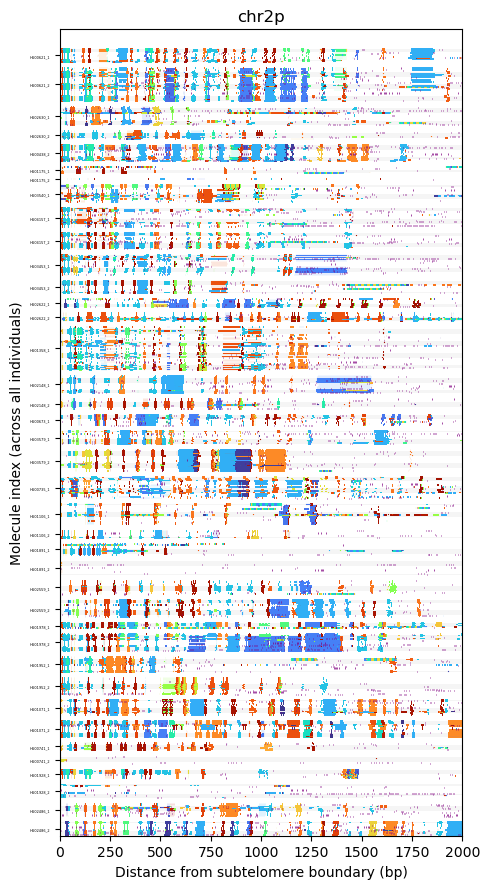

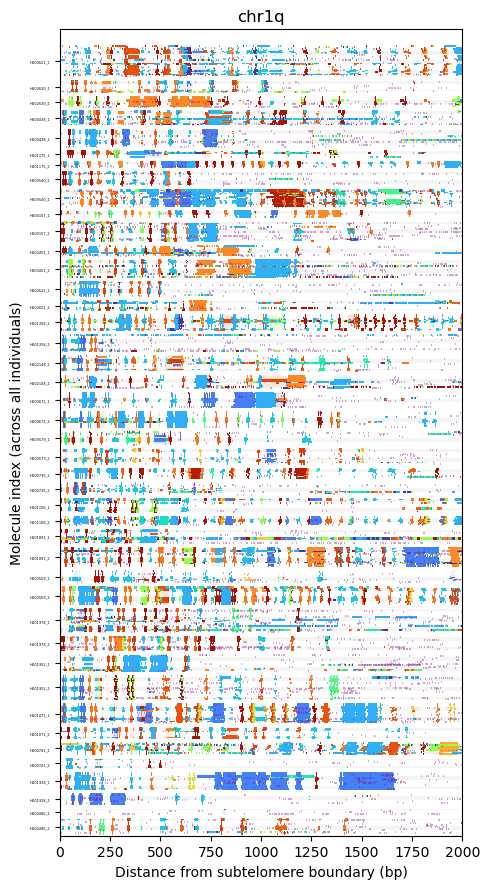

In [21]:
for ca in ['chr2p','chr1q']:
    plotTVRs(all_hprc_tsvs,ca,out_name=None)

In [22]:
def load_motif_counts(tsv_path):

    motif_dict = {}
    
    with open(tsv_path, 'r') as f:
        next(f) 
        
        for line in f:
            parts = line.strip().split('\t')
            
            if len(parts) == 3:
                motif, meth_c, total_c = parts
                motif_dict[motif] = [int(meth_c), int(total_c)]
                
    return motif_dict

total_norm_rate_dict = {}

for control_fn in glob(f'data_for_submission/5percent_subsample_methylation_rates_ont_fiberseq/*_ONT.dsa.F2308_random_5percent.bam.m6a.clean.bed.gz.5percent_motif_tsv'):

    label = control_fn.split('/')[-1].split('_')[0]
    
    label_control_dict = load_motif_counts(control_fn)
    
    print(label)
    
    total_norm_rate_dict[label] = label_control_dict 
    


HG00621
HG02486
HG01106
HG00673
HG01175
HG02148
HG01358
HG03540
HG02257
HG01928
HG01071
HG01978
HG03453
HG00438
HG03579
HG01891
HG04157
HG00741
HG02559
HG02630
HG02622
HG01952
HG00735


In [23]:
def id_motifs(seq, motif, m6a_coords):
    start = 0
    m6a_count = 0 
    motif_count = 0 
    mlen = len(motif)
    
    while True:
        i = seq.find(motif, start)
        if i == -1:
            break

        motif_count += 1 

        if np.sum((m6a_coords >= i) & (m6a_coords < i + mlen)) > 0:
            m6a_count += 1

        start = i + mlen

    return m6a_count, motif_count       

ALL_MOTIFS = [
'TGAGGG',
'GTAGGG',
'CTAGGG',
'TTAAGG',
'TCAGGG',
'TTAGAG',
'GTTAAG']

records = []

for label, tsv in tqdm(zip(all_hprc_labels, all_hprc_tsvs)):

    tsv['telo_len'] = tsv['teloseq'].apply(len) 
    tmp_tsv = tsv[ (tsv.telo_len > 1_000) & (tsv.telo_len < 10_000) ]
    
    telo_counts = {m: {'m6a': 0, 'total': 0} for m in ALL_MOTIFS}
    TTAGGG_m6A_count, TTAGGG_total_count = 0, 0
    
    for _, row in tmp_tsv.iterrows():
        
        teloseq_str = str(row.teloseq)
        m6a = str(row.centered_m6a_positions)
        
        if not m6a or m6a.lower() == 'nan':
            continue
            
        m6a_array = np.fromstring(m6a, sep=',', dtype=int)[1:-1]
        m6a_array_filter = m6a_array[m6a_array >= 0]
        
        if len(m6a_array_filter) == 0:
            continue
            
        if row.strand == "-": 
            m6a_array_filter = m6a_array_filter - 1
            
        if m6a_array_filter[0] >= len(teloseq_str):
            continue
            
        base_of_interest = teloseq_str[m6a_array_filter[0]]
        
        for motif in ALL_MOTIFS:
            m6a_count, motif_count = id_motifs(teloseq_str, motif, m6a_array_filter)
            telo_counts[motif]['m6a'] += m6a_count
            telo_counts[motif]['total'] += motif_count

        mol_ttaggg_m6a, mol_ttaggg_tot = id_motifs(teloseq_str, "TTAGGG", m6a_array_filter)
        TTAGGG_m6A_count += mol_ttaggg_m6a
        TTAGGG_total_count += mol_ttaggg_tot
        
    sample_genome_stats = total_norm_rate_dict.get(label, {})

    records.append({
        'sample': label,
        'motif': 'TTAGGG',
        'telo_m6a_count': TTAGGG_m6A_count,
        'telo_total_count': TTAGGG_total_count,
        'genome_m6a_count': sample_genome_stats.get('TTAGGG', (0, 0))[0],
        'genome_total_count': sample_genome_stats.get('TTAGGG', (0, 0))[1]
    })
    
    for m in ALL_MOTIFS:
        records.append({
            'sample': label,
            'motif': m,
            'telo_m6a_count': telo_counts[m]['m6a'],
            'telo_total_count': telo_counts[m]['total'],
            'genome_m6a_count': sample_genome_stats.get(m, (0, 0))[0],
            'genome_total_count': sample_genome_stats.get(m, (0, 0))[1]
        })

df_motif_counts = pd.DataFrame(records)

22it [01:19,  3.61s/it]


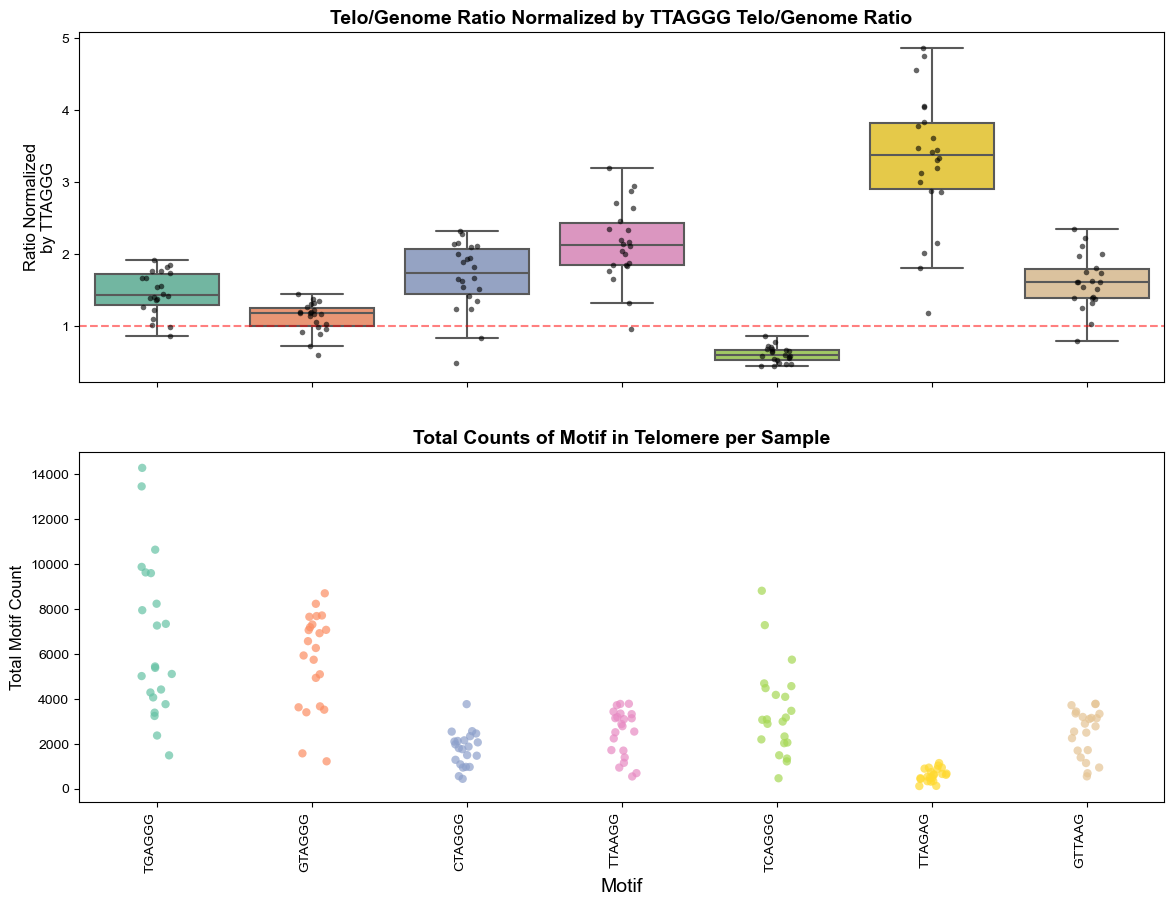

In [24]:
# calculate the base rates for all rows (both motifs and TTAGGG)
df_motif_counts['telo_rate'] = np.where(df_motif_counts['telo_total_count'] > 0, 
                                        df_motif_counts['telo_m6a_count'] / df_motif_counts['telo_total_count'], 
                                        np.nan)

df_motif_counts['genome_rate'] = np.where(df_motif_counts['genome_total_count'] > 0, 
                                          df_motif_counts['genome_m6a_count'] / df_motif_counts['genome_total_count'], 
                                          np.nan)

df_motif_counts['telo_genome_ratio'] = df_motif_counts['telo_rate'] / df_motif_counts['genome_rate']

# isolate the TTAGGG data to use for normalization
df_ttaggg = df_motif_counts[df_motif_counts['motif'] == 'TTAGGG'].copy()

ttaggg_ratio_map = dict(zip(df_ttaggg['sample'], df_ttaggg['telo_genome_ratio']))

# filter out TTAGGG from the main dataframe so it doesn't appear as its own motif box
df_plot = df_motif_counts[df_motif_counts['motif'] != 'TTAGGG'].copy()

# calc metric (motif telo/genome Ratio) / (TTAGGG telo/genome ratio)
df_plot['ttaggg_norm_ratio'] = df_plot['telo_genome_ratio'] / df_plot['sample'].map(ttaggg_ratio_map)

# generate the 2-row subplot
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
sns.set_theme(style="whitegrid")

palette = sns.color_palette("Set2", n_colors=df_plot['motif'].nunique())

def plot_box_with_points(ax, y_col, ylabel, title):
    sns.boxplot(data=df_plot, x='motif', y=y_col, ax=ax, palette=palette, showfliers=False)
    sns.stripplot(data=df_plot, x='motif', y=y_col, ax=ax, color='black', alpha=0.6, jitter=True, size=4)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('')

plot_box_with_points(axes[0], 'ttaggg_norm_ratio', 'Ratio Normalized\nby TTAGGG', 'Telo/Genome Ratio Normalized by TTAGGG Telo/Genome Ratio')
axes[0].axhline(1.0, color='red', linestyle='--', alpha=0.5) # Add reference line at 1.0

sns.stripplot(data=df_plot, x='motif', y='telo_total_count', ax=axes[1], palette=palette, jitter=True, size=6, alpha=0.7)
axes[1].set_ylabel('Total Motif Count', fontsize=12)
axes[1].set_title('Total Counts of Motif in Telomere per Sample', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Motif', fontsize=14)

for tick in axes[1].get_xticklabels():
    tick.set_rotation(90)
    tick.set_ha('right')

plt.show()